In [1]:
"""
Modelisation - Customer Personality Analysis
Input: data/processed/df_features.csv
Output: data/processed/df_features.csv

Modèles à utiliser:
    1. K-Means sans ACP
    2. K-Means avec ACP
    3. GMM avec ACP
    4. CAH avec ACP

Métrique: Silhouette Score
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

print("imports réussis")
sns.set_theme(style="whitegrid")

imports réussis


In [2]:
# Chargement des données

PATH_DATA = "../data/processed/df_features.csv"
df = pd.read_csv(PATH_DATA)
print(f"Jeu de données {df.shape}")


Jeu de données (2212, 27)


In [3]:
# --- 1. Encodage et sélection des features

df_model = df.copy()

education_order = {
    "Basic"     : 0,
    "2n Cycle"  : 1,
    "Graduation": 2,
    "Master"    : 3,
    "PhD"       : 4,
}

df_model["Education"] = df_model["Education"].map(education_order)


marital_order = {
    "Single"  : 0,
    "Together": 1,
    "Married" : 2,
    "Divorced": 3,
    "Widow"   : 4,
}

df_model["Marital_Status"] = df_model["Marital_Status"].map(marital_order)


# Selection des features pour le clustering
cols_to_exclure = [
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
    "AcceptedCmp4", "AcceptedCmp5",
    "Complain",
    "Response",
]

features = df_model.drop(columns=cols_to_exclure)

print(f"Features pour le clustering: {features.shape[1]} colonnes")
print(features.columns.tolist())
print(features.shape)


Features pour le clustering: 20 colonnes
['Education', 'Marital_Status', 'Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Age', 'Seniority', 'Total_spend', 'Total_campaign', 'Nb_kids']
(2212, 20)


In [4]:
# --- 2. Standardisation des données ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print(f"Moyenne après le scaling : {X_scaled.mean(axis=0).round(2)} ")
print(f"Ecart type après le scaling : {X_scaled.std(axis=0).round(2)}")

Moyenne après le scaling : [-0. -0. -0.  0.  0.  0.  0. -0.  0.  0. -0. -0. -0. -0.  0.  0. -0.  0.
 -0.  0.] 
Ecart type après le scaling : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


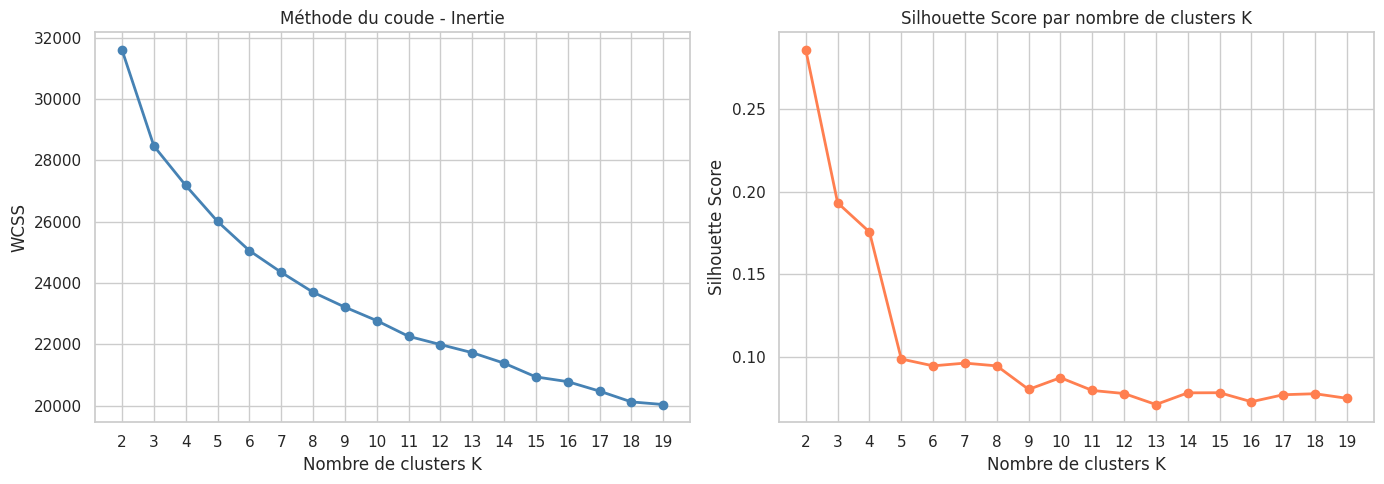


 Silhouette Scores :
2 ->: 0.2858497438548974
3 ->: 0.19335588148571384
4 ->: 0.1757195661291265
5 ->: 0.09883265382972153
6 ->: 0.0946882387938029
7 ->: 0.09635063390291355
8 ->: 0.09467044283363028
9 ->: 0.08042784089253596
10 ->: 0.08751690611817173
11 ->: 0.07979237879131629
12 ->: 0.07793610885048455
13 ->: 0.07127806325598089
14 ->: 0.0783506368434057
15 ->: 0.07842549741953744
16 ->: 0.07295898120063495
17 ->: 0.07720668897481635
18 ->: 0.07781469724427821
19 ->: 0.0750438608497908


In [5]:
# --- 3. Choix du K optimal sans ACP
# Métriques utilisées: Elbow et Silhouette Score

K_range = range(2,20)
wcss_scores = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    wcss_scores.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))


# Visualisation
figure, axes = plt.subplots(1, 2, figsize=(14,5))

# Elbow (wcss)
axes[0].plot(K_range, wcss_scores, marker ="o", color="steelblue", linewidth=2)
axes[0].set_xticks(K_range)
axes[0].set_title("Méthode du coude - Inertie")
axes[0].set_xlabel("Nombre de clusters K")
axes[0].set_ylabel("WCSS")

# Silhouette
axes[1].plot(K_range, silhouettes, marker = "o", color="coral", linewidth=2)
axes[1].set_xticks(K_range)
axes[1].set_title("Silhouette Score par nombre de clusters K")
axes[1].set_xlabel("Nombre de clusters K")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()


print("\n Silhouette Scores :")
for k, s in zip(K_range, silhouettes):
    print(f"{k} ->: {s}")


Dimension avant l'ACP: 20
Dimension après ACP:  13
Variance expliquée : 0.91


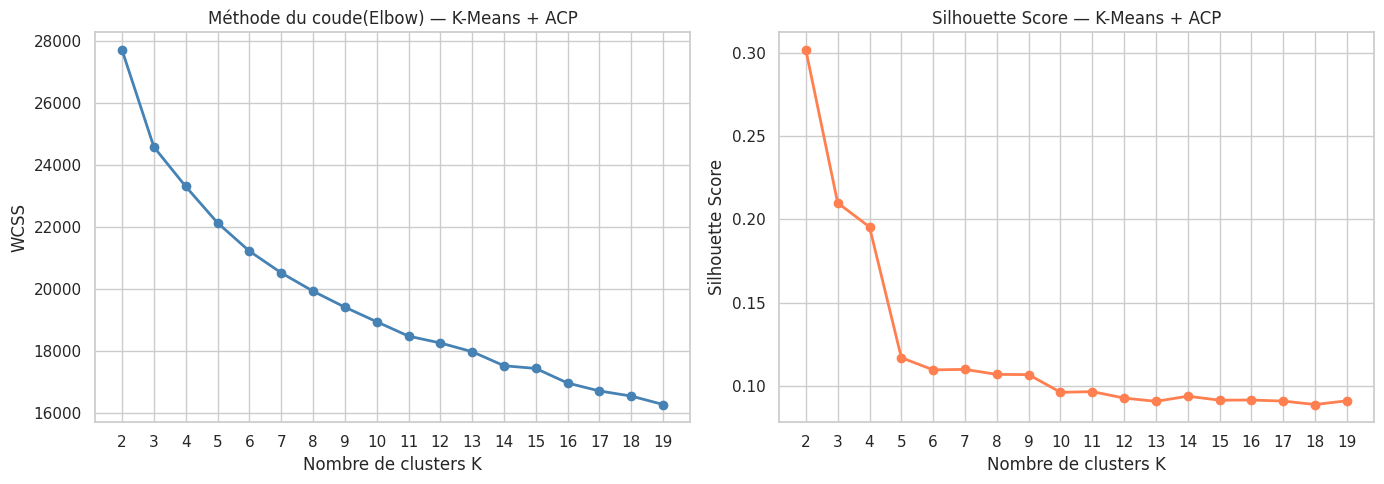


Silhouette Scores K-Means + ACP :
  K=2 → 0.3016
  K=3 → 0.2099
  K=4 → 0.1955
  K=5 → 0.1171
  K=6 → 0.1098
  K=7 → 0.1101
  K=8 → 0.1071
  K=9 → 0.1069
  K=10 → 0.0963
  K=11 → 0.0967
  K=12 → 0.0929
  K=13 → 0.0909
  K=14 → 0.0940
  K=15 → 0.0916
  K=16 → 0.0917
  K=17 → 0.0911
  K=18 → 0.0890
  K=19 → 0.0912


In [6]:
# --- Choix su K optimal avec ACP

pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Dimension avant l'ACP: {X_scaled.shape[1]}")
print(f"Dimension après ACP:  {X_pca.shape[1]}")
print(f"Variance expliquée : {pca.explained_variance_ratio_.sum().round(2)}")


K_range = range(2,20)
wcss_scores = []
silhouettes = []


for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    wcss_scores.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))


figure, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(K_range, wcss_scores, marker="o", color="steelblue", linewidth=2)
axes[0].set_title("Méthode du coude(Elbow) — K-Means + ACP")
axes[0].set_xlabel("Nombre de clusters K")
axes[0].set_xticks(K_range)
axes[0].set_ylabel("WCSS")

axes[1].plot(K_range, silhouettes, marker="o", color="coral", linewidth=2)
axes[1].set_title("Silhouette Score — K-Means + ACP")
axes[1].set_xlabel("Nombre de clusters K")
axes[1].set_xticks(K_range)
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

print("\nSilhouette Scores K-Means + ACP :")
for k, s in zip(K_range, silhouettes):
    print(f"  K={k} → {s:.4f}")


In [38]:
# --- Modèle final: K-Means + ACP, K=3

# Configuration

final_cols_to_exclure = cols_to_exclure

features = df_model.drop(columns=final_cols_to_exclure)

# Standardisation
scaler = StandardScaler()
X_n = scaler.fit_transform(features)


# ACP
pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_n)


# Modèle final
K_final = 3
km_final = KMeans(n_clusters=K_final, random_state=42, n_init=10)
labels = km_final.fit_predict(X_pca)

# Ajout des labels au dataframe original
df_model["Cluster"] = labels


# Distribution des clusters
print("Distribution des clusters: ")
print(df_model["Cluster"].value_counts().sort_index())
print(f"\n Silhouette Score final: {silhouette_score(X_pca, labels):.4f}")

Distribution des clusters: 
Cluster
0     634
1    1029
2     549
Name: count, dtype: int64

 Silhouette Score final: 0.2330


In [46]:
# -- Interpretation

cols_profil = [
    "Income", "Age", "Total_spend",
    "MntWines", "MntMeatProducts", "MntGoldProds",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
    "Total_campaign", "Recency", "Cluster", "Seniority", "Nb_kids"
]

profil = df_model[cols_profil].groupby("Cluster").mean().round(1)
print(profil.T)

Cluster                    0        1        2
Income               75309.3  35186.8  56429.2
Age                     45.8     42.5     49.2
Total_spend           1353.3     97.9    700.5
MntWines               608.5     41.8    449.0
MntMeatProducts        434.4     22.8    128.5
MntGoldProds            78.3     15.3     57.9
NumWebPurchases          5.3      2.1      6.5
NumCatalogPurchases      5.9      0.6      2.9
NumStorePurchases        8.4      3.2      7.6
Total_campaign           1.0      0.2      0.4
Recency                 49.4     49.4     48.0
Nb_kids                  0.3      1.2      1.2
Seniority              358.8    315.3    419.9
Nb_kids                  0.3      1.2      1.2


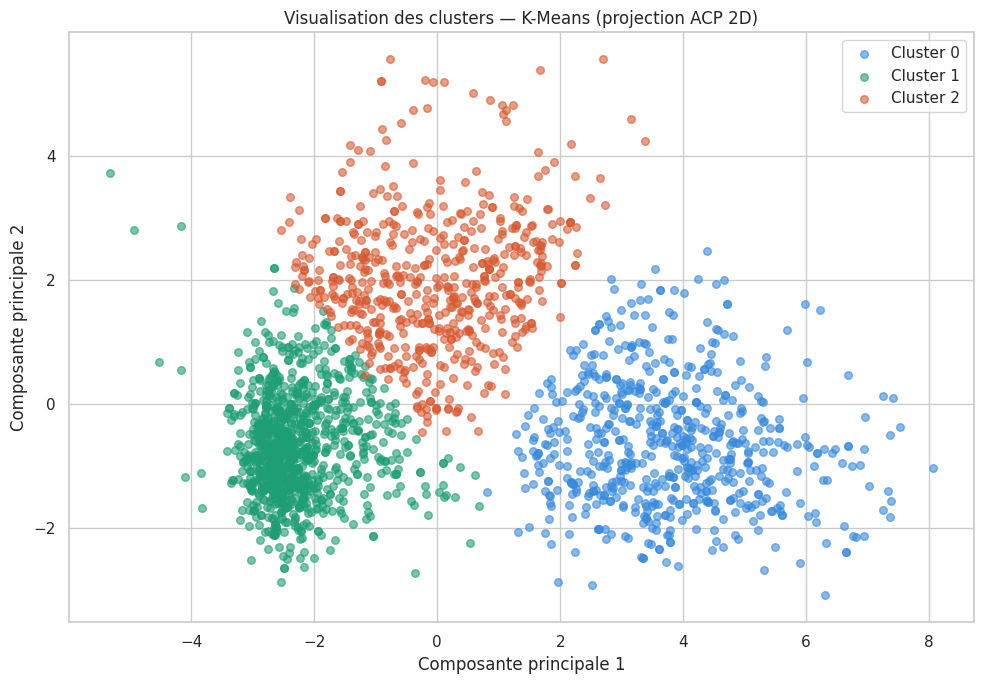

In [40]:
# --- Visualisation 2D --

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_n)

plt.figure(figsize=(10, 7))
colors = ["#378ADD", "#1D9E75", "#D85A30"]

for cluster in range(K_final):
    mask = labels == cluster
    plt.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=colors[cluster],
        label=f"Cluster {cluster}",
        alpha=0.6, s=30
    )

plt.title("Visualisation des clusters — K-Means (projection ACP 2D)")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend()
plt.tight_layout()
plt.show()

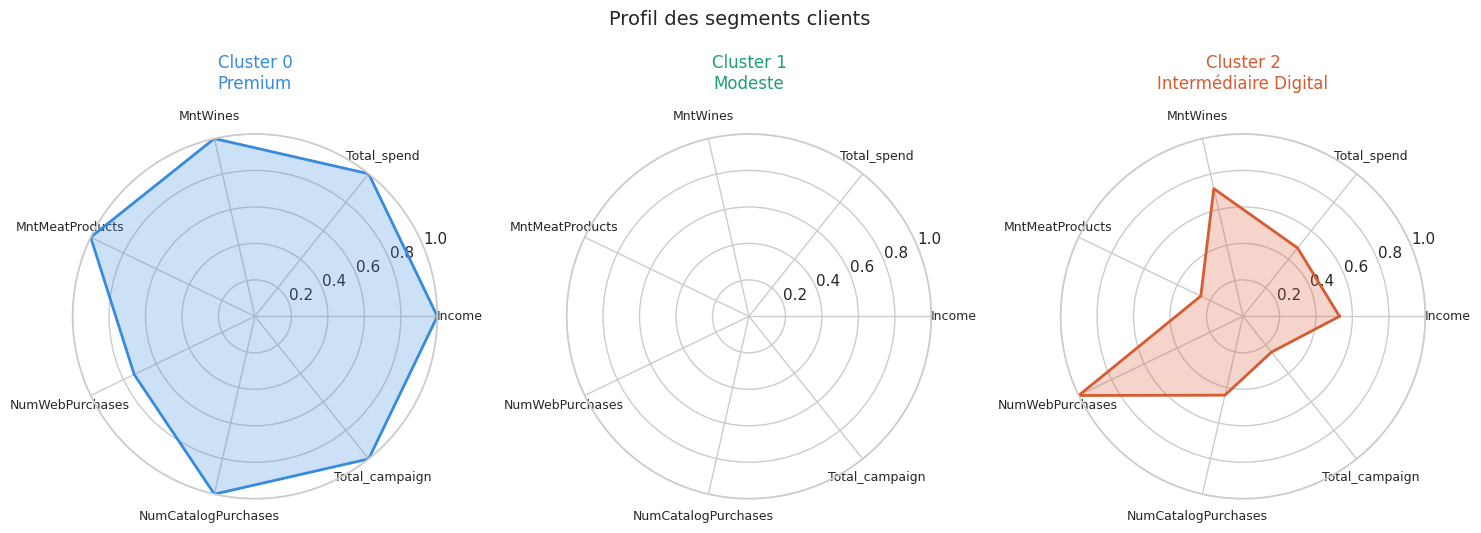

In [47]:
# --- RADAR CHART — profil des clusters ---
import numpy as np

cols_radar = [
    "Income", "Total_spend", "MntWines", "MntMeatProducts",
    "NumWebPurchases", "NumCatalogPurchases", "Total_campaign"
]

# Normalisation entre 0 et 1 pour comparer
profil_norm = df_model.groupby("Cluster")[cols_radar].mean()
profil_norm = (profil_norm - profil_norm.min()) / (profil_norm.max() - profil_norm.min())

# Paramètres radar
N = len(cols_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 3, figsize=(15, 5),
                          subplot_kw=dict(polar=True))

colors  = ["#378ADD", "#1D9E75", "#D85A30"]
noms    = ["Premium", "Modeste", "Intermédiaire Digital"]

for i, ax in enumerate(axes):
    values = profil_norm.iloc[i].tolist()
    values += values[:1]

    ax.plot(angles, values, color=colors[i], linewidth=2)
    ax.fill(angles, values, color=colors[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(cols_radar, size=9)
    ax.set_title(f"Cluster {i}\n{noms[i]}", size=12,
                 color=colors[i], pad=15)
    ax.set_ylim(0, 1)

plt.suptitle("Profil des segments clients", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

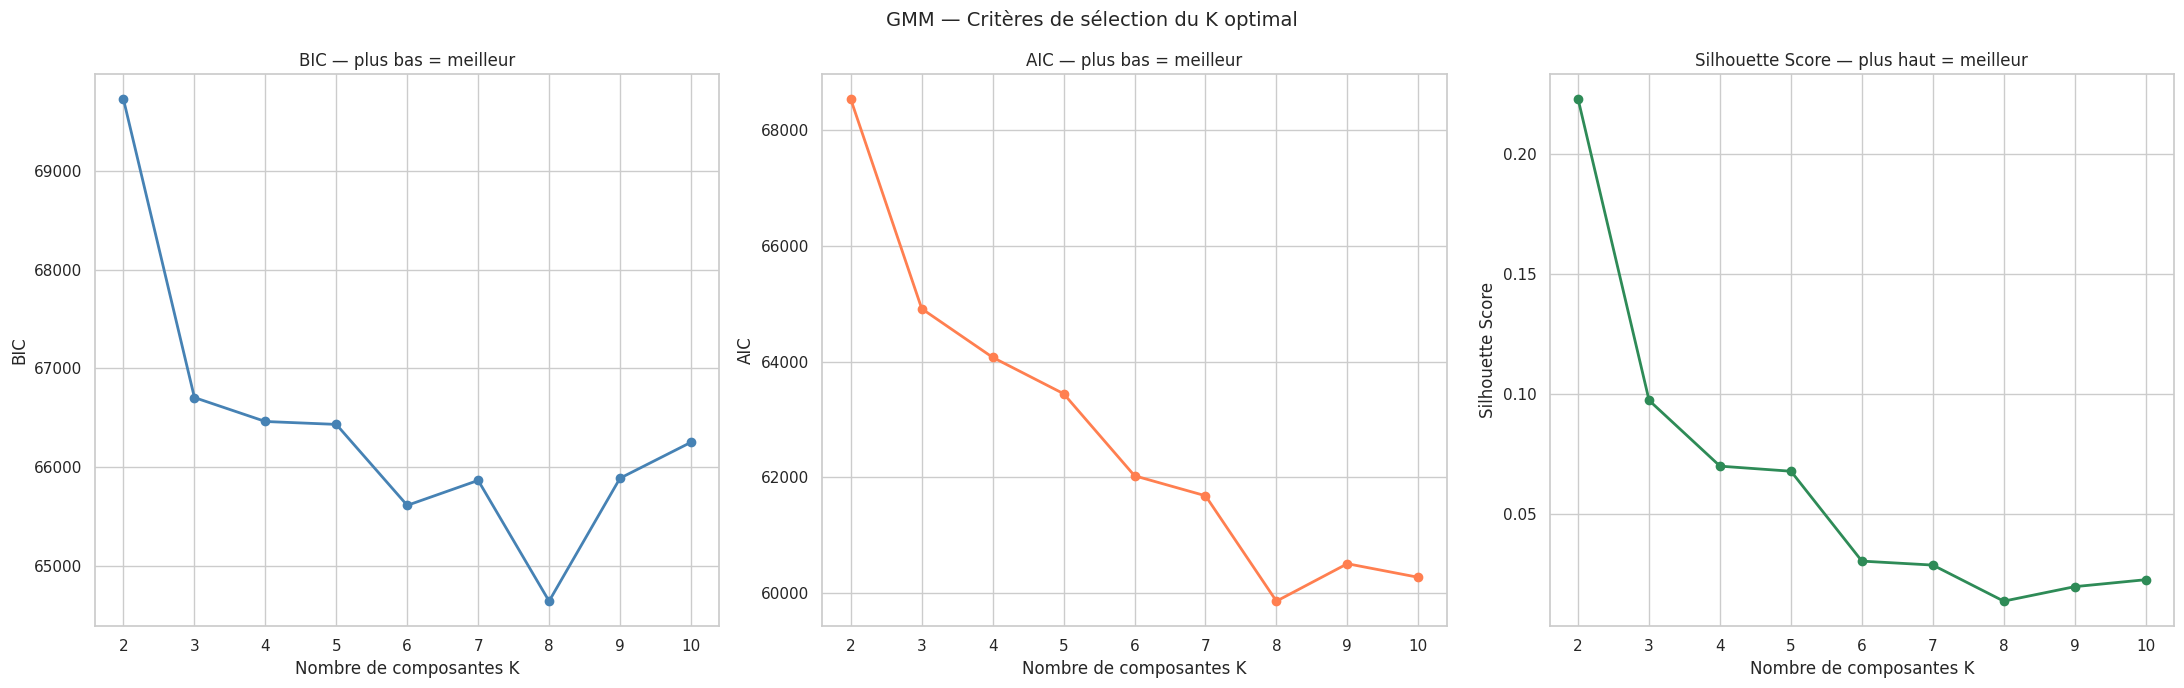


   K          BIC          AIC   Silhouette
--------------------------------------------
   2      69724.1      68532.4       0.2227
   3      66702.9      64912.6       0.0975
   4      66460.3      64071.3       0.0701
   5      66430.9      63443.2       0.0680
   6      65610.5      62024.1       0.0306
   7      65863.6      61678.6       0.0289
   8      64639.6      59855.9       0.0139
   9      65885.7      60503.4       0.0199
  10      66249.5      60268.4       0.0228


In [50]:
# --- GMM - Recherche du K optimal --

K_range = range(2, 11)
bic_scores = []
aic_scores = []
sil_scores = []

for k in K_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        n_init=5
    )
    gmm.fit(X_pca)
    labels_gmm = gmm.predict(X_pca)

    bic_scores.append(gmm.bic(X_pca))
    aic_scores.append(gmm.aic(X_pca))
    sil_scores.append(silhouette_score(X_pca, labels_gmm))


# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

axes[0].plot(K_range, bic_scores, marker="o", color="steelblue", linewidth=2)
axes[0].set_title("BIC — plus bas = meilleur")
axes[0].set_xlabel("Nombre de clusters K")
axes[0].set_ylabel("BIC")
axes[0].set_xticks(K_range)

axes[1].plot(K_range, aic_scores, marker="o", color="coral", linewidth=2)
axes[1].set_title("AIC — plus bas = meilleur")
axes[1].set_xlabel("Nombre de clusters K")
axes[1].set_ylabel("AIC")
axes[1].set_xticks(K_range)

axes[2].plot(K_range, sil_scores, marker="o", color="seagreen", linewidth=2)
axes[2].set_title("Silhouette Score — plus haut = meilleur")
axes[2].set_xlabel("Nombre de clusters K")
axes[2].set_ylabel("Silhouette Score")
axes[2].set_xticks(K_range)

plt.suptitle("GMM — Critères de sélection du K optimal", fontsize=14)
plt.tight_layout()
plt.show()

# Tableau récapitulatif
print(f"\n{'K':>4} {'BIC':>12} {'AIC':>12} {'Silhouette':>12}")
print("-" * 44)
for k, bic, aic, sil in zip(K_range, bic_scores, aic_scores, sil_scores):
    print(f"{k:>4} {bic:>12.1f} {aic:>12.1f} {sil:>12.4f}")

In [51]:
# --- GMM modèle final K=8 ---
gmm_final = GaussianMixture(
    n_components=8,
    covariance_type="full",
    random_state=42,
    n_init=5
)
gmm_final.fit(X_pca)
labels_gmm = gmm_final.predict(X_pca)
probas_gmm  = gmm_final.predict_proba(X_pca)

df_model["Cluster_GMM"] = labels_gmm

# Distribution
print("Distribution GMM K=8 :")
print(df_model["Cluster_GMM"].value_counts().sort_index())
print(f"\nSilhouette Score GMM K=8 : {silhouette_score(X_pca, labels_gmm):.4f}")

# Profil des clusters
cols_profil = [
    "Income", "Age", "Total_spend",
    "MntWines", "MntMeatProducts",
    "NumWebPurchases", "NumCatalogPurchases",
    "Total_campaign", "Nb_kids", "Cluster_GMM"
]

profil_gmm = df_model[cols_profil].groupby("Cluster_GMM").mean().round(1)
print("\nProfil des clusters GMM :")
print(profil_gmm.T)

Distribution GMM K=8 :
Cluster_GMM
0    484
1    356
2    305
3     29
4    199
5    305
6    340
7    194
Name: count, dtype: int64

Silhouette Score GMM K=8 : 0.0139

Profil des clusters GMM :
Cluster_GMM                0        1        2        3        4        5  \
Income               32692.3  78252.1  63252.3  76018.0  31616.3  63219.0   
Age                     41.4     45.5     48.2     48.1     42.9     45.9   
Total_spend             45.3   1477.4   1051.6   1197.3     74.8    867.0   
MntWines                19.4    671.4    627.1    447.1     29.1    378.6   
MntMeatProducts         11.6    512.4    207.2    509.9     17.3    231.0   
NumWebPurchases          1.5      4.8      6.4      4.9      2.0      6.0   
NumCatalogPurchases      0.1      6.2      4.4      9.0      0.8      3.7   
Total_campaign           0.0      1.3      0.9      0.0      0.6      0.0   
Nb_kids                  1.3      0.0      1.0      0.5      1.5      0.8   

Cluster_GMM                6      

In [52]:
# GMM K=3 — comparaison directe avec K-Means
gmm_k3 = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42,
    n_init=5
)
gmm_k3.fit(X_pca)
labels_gmm3 = gmm_k3.predict(X_pca)
probas_gmm3 = gmm_k3.predict_proba(X_pca)

df_model["Cluster_GMM3"] = labels_gmm3

print("Distribution GMM K=3 :")
print(df_model["Cluster_GMM3"].value_counts().sort_index())
print(f"\nSilhouette GMM K=3  : {silhouette_score(X_pca, labels_gmm3):.4f}")
print(f"Silhouette KMeans K=3: 0.2099")

# Clients à la frontière — la valeur ajoutée de GMM
probas_max = probas_gmm3.max(axis=1)
clients_ambigus = (probas_max < 0.70).sum()
print(f"\nClients avec probabilité < 70% : {clients_ambigus}")
print(f"→ Ces clients sont à la frontière entre deux segments")
print(f"→ Représentent {clients_ambigus/len(df_model)*100:.1f}% de la base")

Distribution GMM K=3 :
Cluster_GMM3
0    669
1    919
2    624
Name: count, dtype: int64

Silhouette GMM K=3  : 0.0975
Silhouette KMeans K=3: 0.2099

Clients avec probabilité < 70% : 46
→ Ces clients sont à la frontière entre deux segments
→ Représentent 2.1% de la base


Matrice de linkage construite : (2211, 4)
→ Chaque ligne = une fusion
→ Colonnes : [cluster_A, cluster_B, distance, nb_points]


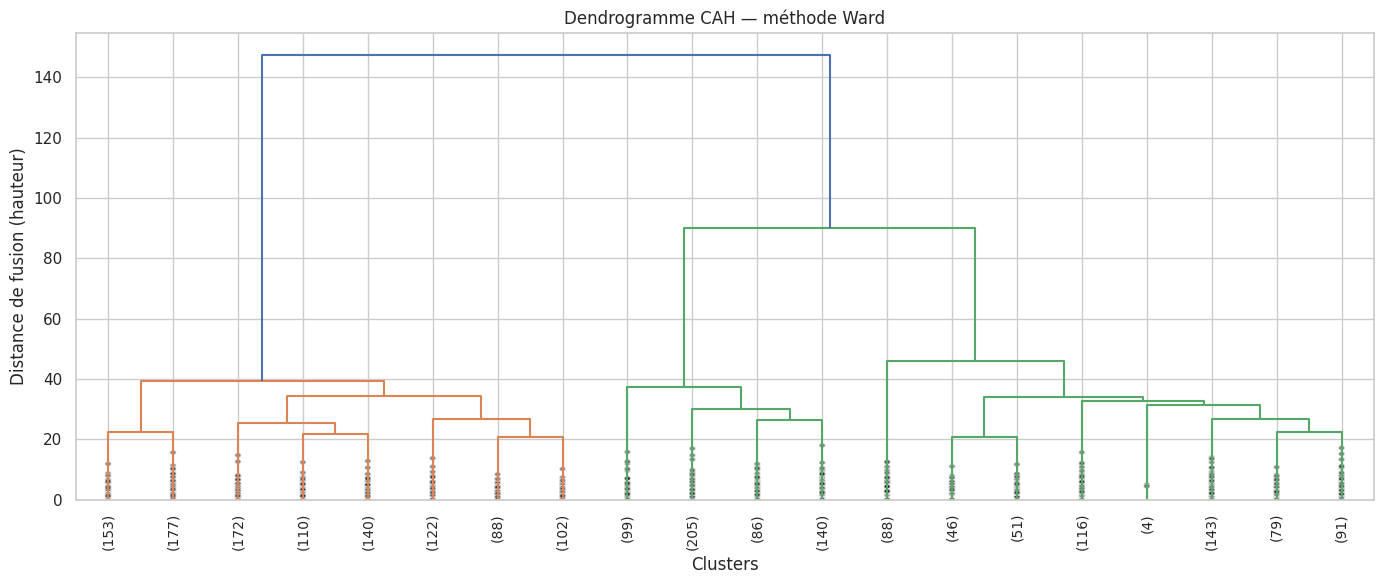

In [7]:
# --- CAH — Classification Ascendante Hiérarchique ---

# CAH sur X_pca — même données que K-Means et GMM
# méthode Ward : minimise la variance intra-cluster à chaque fusion
Z = linkage(X_pca, method="ward")

print(f"Matrice de linkage construite : {Z.shape}")
print("→ Chaque ligne = une fusion")
print("→ Colonnes : [cluster_A, cluster_B, distance, nb_points]")

# --- Dendrogramme ---

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode="lastp",  # affiche uniquement les p dernières fusions
    p=20,                    # → les 20 dernières fusions (plus lisible)
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
)

plt.title("Dendrogramme CAH — méthode Ward")
plt.xlabel("Clusters")
plt.ylabel("Distance de fusion (hauteur)")
plt.tight_layout()
plt.show()

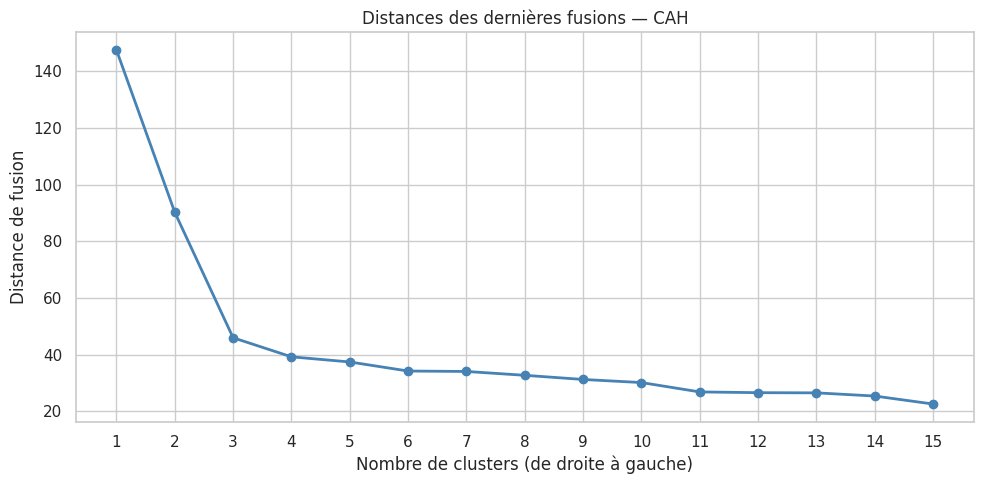

Distances des dernières fusions :
  1 cluster(s) → 147.4092
  2 cluster(s) → 90.1919
  3 cluster(s) → 45.9753
  4 cluster(s) → 39.2552
  5 cluster(s) → 37.4422
  6 cluster(s) → 34.2461
  7 cluster(s) → 34.0932
  8 cluster(s) → 32.7391
  9 cluster(s) → 31.2727
  10 cluster(s) → 30.1802
  11 cluster(s) → 26.8797
  12 cluster(s) → 26.6178
  13 cluster(s) → 26.5529
  14 cluster(s) → 25.4282
  15 cluster(s) → 22.6073


In [57]:
# --- Courbe des distances de fusion ---

# Les distances de fusion sont dans la 3e colonne de Z
distances = Z[:, 2]

# On regarde les dernières fusions — les plus significatives
n_fusions = 15
last_distances = distances[-n_fusions:][::-1]

plt.figure(figsize=(10, 5))
plt.plot(range(1, n_fusions + 1), last_distances,marker="o", color="steelblue", linewidth=2)
plt.title("Distances des dernières fusions — CAH")
plt.xlabel("Nombre de clusters (de droite à gauche)")
plt.ylabel("Distance de fusion")
plt.xticks(range(1, n_fusions + 1))
plt.tight_layout()
plt.show()

print("Distances des dernières fusions :")
for i, d in enumerate(last_distances, 1):
    print(f"  {i} cluster(s) → {d:.4f}")

In [58]:
# --- Couper l'arbre à K=3 ---

K_CAH = 3
labels_cah = fcluster(Z, K_CAH, criterion="maxclust") - 1

df_model["Cluster_CAH"] = labels_cah

print(f"Distribution CAH K=3 :")
print(df_model["Cluster_CAH"].value_counts().sort_index())
print(f"\nSilhouette CAH K=3 : {silhouette_score(X_pca, labels_cah):.4f}")

Distribution CAH K=3 :
Cluster_CAH
0    1064
1     530
2     618
Name: count, dtype: int64

Silhouette CAH K=3 : 0.1966


In [59]:
# --- Profil des clusters CAH ---

cols_profil = [
    "Income", "Age", "Total_spend",
    "MntWines", "MntMeatProducts",
    "NumWebPurchases", "NumCatalogPurchases",
    "Total_campaign", "Nb_kids", "Cluster_CAH"
]

profil_cah = df_model[cols_profil].groupby("Cluster_CAH").mean().round(1)
print("\nProfil des clusters CAH :")
print(profil_cah.T)


Profil des clusters CAH :
Cluster_CAH                0        1        2
Income               36038.1  57431.3  74676.0
Age                     43.3     47.7     45.9
Total_spend            113.0    773.9   1315.4
MntWines                51.6    502.0    573.4
MntMeatProducts         25.9    143.4    430.3
NumWebPurchases          2.2      6.5      5.3
NumCatalogPurchases      0.6      3.2      5.7
Total_campaign           0.2      0.4      0.9
Nb_kids                  1.2      1.2      0.3
